In [1]:
import boto3
import pandas as pd
from io import StringIO
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from datetime import datetime
from sagemaker import get_execution_role, session, Session
session = Session()

# S3 configuration
bucket = session.default_bucket()
s3 = boto3.client('s3')
# Path for report folder generated by sagemake at the runtime when pipeline executes the step
prefix = "DDOS-Intrusion-Detection-Pipeline-CICD-Batch-Inference/1j0cvvirr5gg/EvaluateBatchPredictions/output/inference-report"  

response = s3.list_objects_v2(Bucket=bucket, Prefix=prefix)

for obj in response.get('Contents', []):
    if "inference-eval.json" in obj['Key']:
        print("Found:", obj['Key'])


sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
Found: DDOS-Intrusion-Detection-Pipeline-CICD-Batch-Inference/1j0cvvirr5gg/EvaluateBatchPredictions/output/inference-report/inference-eval.json


In [2]:
import json
from datetime import datetime
import boto3

s3 = boto3.client("s3")
obj = s3.get_object(Bucket=bucket, Key=f"{prefix}/inference-eval.json" )

# Load JSON content
metrics_data = json.load(obj["Body"])


# Initialize CloudWatch client
cloudwatch = boto3.client("cloudwatch")
namespace = "DDoSDetection/ModelEvaluationBatchInference"

# Push metrics to CloudWatch
for metric_name in ["accuracy", "precision", "recall", "f1"]:
    if metric_name in metrics_data:
        cloudwatch.put_metric_data(
            Namespace=namespace,
            MetricData=[
                {
                    "MetricName": metric_name,
                    "Timestamp": datetime.utcnow(),
                    "Value": metrics_data[metric_name],
                    "Unit": "None"
                }
            ]
        )

print("Metrics pushed to CloudWatch successfully.")

Metrics pushed to CloudWatch successfully.


/tmp/ipykernel_437/213992411.py:24: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "Timestamp": datetime.utcnow(),


In [3]:
metrics_data

{'accuracy': 99.87571464081532,
 'precision': 99.97848116123478,
 'recall': 99.80666328164668,
 'f1': 99.89249833861068}

In [4]:
response = cloudwatch.list_metrics(Namespace="DDoSDetection/ModelEvaluationBatchInference")
print([m["MetricName"] for m in response.get("Metrics", [])])

['recall', 'precision', 'f1', 'accuracy']


In [5]:
# Define thresholds
MODEL_ACCURACY_TH =  0.8
MODEL_PRECISION_TH =  0.8
MODEL_F1_TH =  0.6
MODEL_F2_TH =  0.6
MODEL_AUC_TH =  0.6

In [6]:
# Create CloudWatch client
cw_client = boto3.Session().client("cloudwatch")

## List the CW metrics generated

In [7]:
endpoint_name = 'sm-DDOS-detection-model-monitor-2025-06-15-2139'
ddos_monitor_schedule_name = 'DDOS-monitoring-schedule-2025-06-15-2232'
namespace = "aws/sagemaker/Endpoints/ddos-model-metrics"
cw_dimensions = [
    {"Name": "Endpoint", "Value": endpoint_name},
    {"Name": "MonitoringSchedule", "Value": ddos_monitor_schedule_name},
]

In [8]:
# List metrics through the pagination interface
paginator = cw_client.get_paginator("list_metrics")

for response in paginator.paginate(Dimensions=cw_dimensions, Namespace=namespace):
    model_quality_metrics = response["Metrics"]
    for metric in model_quality_metrics:
        print(metric["MetricName"])

## Create a CloudWatch Alarm

Based on the cloud watch metrics create a cloud watch alarm when a specific metric does not meet the threshold configured. Create an alarm if the metric's value of the model fall below the threshold.

In [9]:
monitor_model_metrics = {    
    "accuracy": MODEL_ACCURACY_TH,
    "precision": MODEL_PRECISION_TH,
    "f1": MODEL_F1_TH,
    "f2": MODEL_F2_TH,
    "auc": MODEL_AUC_TH
}

namespace = "aws/sagemaker/Endpoints/model-metrics"

for metric_name, model_quality_drift_threshold in monitor_model_metrics.items():
    alarm_name = f"DDOS-MODEL_QUALITY_{metric_name.upper()}"
    alarm_desc = f"Trigger a CloudWatch alarm when {metric_name.upper()} drifts below the threshold {model_quality_drift_threshold}"
    cw_client.put_metric_alarm(
        AlarmName=alarm_name,
        AlarmDescription=alarm_desc,
        ActionsEnabled=True,
        MetricName=metric_name,
        Namespace=namespace,
        Statistic="Average",
        Dimensions=[
            {"Name": "Endpoint", "Value": endpoint_name},
            {"Name": "MonitoringSchedule", "Value": ddos_monitor_schedule_name},
        ],
        Period=600,
        EvaluationPeriods=1,
        DatapointsToAlarm=1,
        Threshold=model_quality_drift_threshold,
        ComparisonOperator="LessThanOrEqualToThreshold",
        TreatMissingData="breaching",
    )

## Validation
CloudWatch dashboard

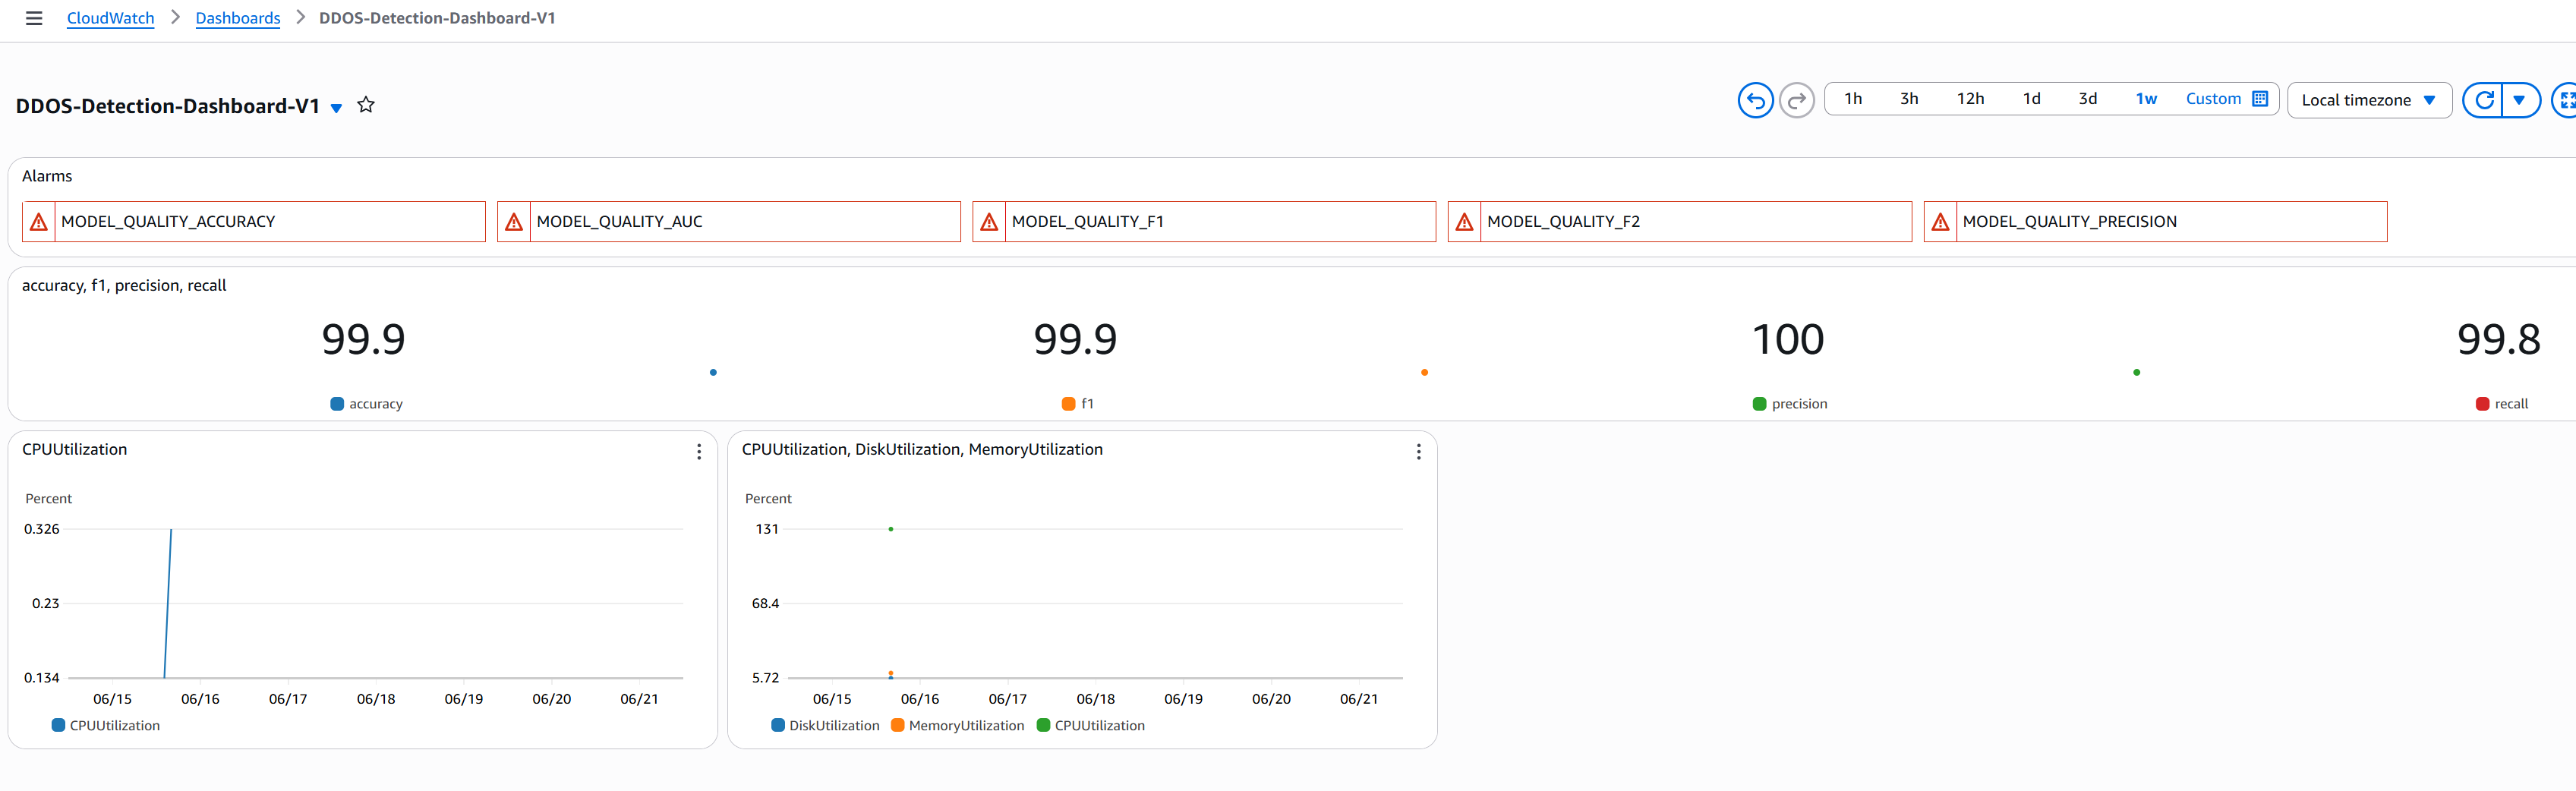

In [10]:
# Read the dashboard JSON from file (stored from UI)
with open("cloudwatch-ddos-detection-dashboard.json", "r") as f:
    dashboard_body = f.read()

# Create the dashboard
cloudwatch = boto3.client("cloudwatch")

cloudwatch.put_dashboard(
    DashboardName="DDOS-Detection-Dashboard-V1",
    DashboardBody=dashboard_body
)

{'DashboardValidationMessages': [],
 'ResponseMetadata': {'RequestId': '71c91715-5b79-4a4a-bd68-dd489ed9e57b',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amzn-requestid': '71c91715-5b79-4a4a-bd68-dd489ed9e57b',
   'content-type': 'text/xml',
   'content-length': '292',
   'date': 'Sat, 21 Jun 2025 19:55:09 GMT'},
  'RetryAttempts': 0}}